In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "| device:", device)

# Project config, we'll reuse these later
CONFIG = {
    "vocab_size": 13,   # digits 0-9 + <pad>=10, <bos>=11, <eos>=12
    "seq_len": 6,       # how many digits to sort
    "d_model": 64,      # size of each token's vector
    "n_heads": 4,
}
print(CONFIG)

torch: 2.3.1+cu118 | device: cuda
{'vocab_size': 13, 'seq_len': 6, 'd_model': 64, 'n_heads': 4}


/home/hari/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# 3 items in our "memory". Each key is a 2D vector.
keys = torch.tensor([
    [1.0, 0.0],   # item 0: "points along x"
    [0.0, 1.0],   # item 1: "points along y"
    [1.0, 1.0],   # item 2: "points diagonally"
])

values = torch.tensor([
    [10.0],   # item 0's content
    [20.0],   # item 1's content
    [30.0],   # item 2's content
])

query = torch.tensor([1.0, 0.0])   # "I'm looking for something along x"

scores  = keys @ query
print("scores: ", scores)

weights = F.softmax(scores, dim=0)
print("weights:", weights)

output  = weights @ values
print("output: ", output)

scores:  tensor([1., 0., 1.])
weights: tensor([0.4223, 0.1554, 0.4223])
output:  tensor([20.0000])


In [3]:
import math

def attention(Q, K, V):
    """
    Q: (n_queries, d_k)
    K: (n_keys,    d_k)
    V: (n_keys,    d_v)
    returns: output (n_queries, d_v), weights (n_queries, n_keys)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)   # (n_queries, n_keys)
    weights = F.softmax(scores, dim=-1)                  # each row sums to 1
    return weights @ V, weights

# Reuse our tiny example, but now with TWO queries at once
K = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
V = torch.tensor([[10.0], [20.0], [30.0]])
Q = torch.tensor([[1.0, 0.0],    # query 0: looking along x
                  [0.0, 1.0]])   # query 1: looking along y

out, w = attention(Q, K, V)
print("weights:\n", w)
print("output:\n", out)

# Why scale? Compare softmax on small vs large scores
big = torch.tensor([1.0, 0.0, 1.0]) * 20
print("\nunscaled big scores -> ", F.softmax(big, dim=0))

weights:
 tensor([[0.4011, 0.1978, 0.4011],
        [0.1978, 0.4011, 0.4011]])
output:
 tensor([[20.0000],
        [22.0334]])

unscaled big scores ->  tensor([5.0000e-01, 1.0306e-09, 5.0000e-01])


In [4]:
torch.manual_seed(0)

for d_k in [4, 64, 512]:
    q = torch.randn(10000, d_k)
    k = torch.randn(10000, d_k)
    raw = (q * k).sum(-1)              # 10000 random dot products
    scaled = raw / math.sqrt(d_k)
    print(f"d_k={d_k:4d} | raw std={raw.std():6.2f} | scaled std={scaled.std():5.2f}")

# What does softmax look like on raw scores at d_k=512?
q = torch.randn(1, 512)
K_rand = torch.randn(8, 512)
raw_scores = (q @ K_rand.T).squeeze()
print("\nraw scores:      ", raw_scores.round())
print("softmax (raw):   ", F.softmax(raw_scores, dim=0).round(decimals=3))
print("softmax (scaled):", F.softmax(raw_scores / math.sqrt(512), dim=0).round(decimals=3))

d_k=   4 | raw std=  1.99 | scaled std= 1.00
d_k=  64 | raw std=  8.01 | scaled std= 1.00
d_k= 512 | raw std= 22.49 | scaled std= 0.99

raw scores:       tensor([ -0.,  24.,  34.,   9.,   6., -45.,  16.,  26.])
softmax (raw):    tensor([0.0000, 0.0000, 0.9990, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010])
softmax (scaled): tensor([0.0600, 0.1730, 0.2700, 0.0920, 0.0780, 0.0080, 0.1230, 0.1950])


* self-attention module

In [5]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        Q, K, V = self.W_q(x), self.W_k(x), self.W_v(x)
        return attention(Q, K, V)   # our function from Cell 2 works on batches too

# Try it on random "token embeddings"
sa = SelfAttention(d_model=16)
x = torch.randn(2, 5, 16)          # batch of 2 sequences, 5 tokens each
out, w = sa(x)

print("input :", x.shape)
print("output:", out.shape)
print("weights:", w.shape)
print("row sums:", w[0].sum(-1))
print("\nattention of sequence 0:\n", w[0].detach().round(decimals=2))

input : torch.Size([2, 5, 16])
output: torch.Size([2, 5, 16])
weights: torch.Size([2, 5, 5])
row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)

attention of sequence 0:
 tensor([[0.1300, 0.2100, 0.2800, 0.2200, 0.1600],
        [0.1500, 0.4300, 0.1700, 0.1200, 0.1300],
        [0.2700, 0.1500, 0.1900, 0.2300, 0.1700],
        [0.2800, 0.1400, 0.1200, 0.2200, 0.2300],
        [0.1700, 0.2300, 0.2200, 0.1700, 0.2200]])


In [6]:
torch.manual_seed(1)
x = torch.randn(1, 5, 16)

sa = SelfAttention(d_model=16)
_, w_proj = sa(x)
_, w_raw = attention(x, x, x)

print("with projections (diag):", w_proj[0].diag().detach().round(decimals=2))
print("no projections   (diag):", w_raw[0].diag().detach().round(decimals=2))

with projections (diag): tensor([0.1400, 0.1700, 0.2000, 0.1000, 0.1900])
no projections   (diag): tensor([0.9200, 0.7900, 0.9100, 0.9800, 0.6200])


* causal mask

In [7]:
def causal_mask(n):
    # True where attention is ALLOWED (lower triangle incl. diagonal)
    return torch.tril(torch.ones(n, n, dtype=torch.bool))

print(causal_mask(5).int())

def attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

torch.manual_seed(1)
x = torch.randn(1, 5, 16)
_, w = attention(x, x, x, mask=causal_mask(5))
print(w[0].round(decimals=2))

tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0300, 0.9700, 0.0000, 0.0000, 0.0000],
        [0.0100, 0.0200, 0.9700, 0.0000, 0.0000],
        [0.0000, 0.0100, 0.0000, 0.9800, 0.0000],
        [0.0900, 0.1100, 0.1000, 0.0900, 0.6200]])


* Padding mask

In [8]:
PAD = 10

# Two sequences, padded to length 5
tokens = torch.tensor([
    [3, 7, 1, PAD, PAD],    # real length 3
    [4, 2, 9, 5,   6  ],    # real length 5
])

# True = real token. Shape (batch, 1, n_keys) so it broadcasts over query rows
pad_mask = (tokens != PAD).unsqueeze(1)
print("pad_mask shape:", pad_mask.shape)
print(pad_mask[0].int())

torch.manual_seed(1)
x = torch.randn(2, 5, 16)

# Padding mask only
_, w_pad = attention(x, x, x, mask=pad_mask)
print("\npadding only, sequence 0:\n", w_pad[0].round(decimals=2))

# Combined: allowed only if BOTH masks allow it
combined = pad_mask & causal_mask(5)
_, w_both = attention(x, x, x, mask=combined)
print("\ncausal + padding, sequence 0:\n", w_both[0].round(decimals=2))

pad_mask shape: torch.Size([2, 1, 5])
tensor([[1, 1, 1, 0, 0]], dtype=torch.int32)

padding only, sequence 0:
 tensor([[0.9600, 0.0300, 0.0100, 0.0000, 0.0000],
        [0.0300, 0.9500, 0.0200, 0.0000, 0.0000],
        [0.0100, 0.0200, 0.9700, 0.0000, 0.0000],
        [0.0400, 0.8500, 0.1100, 0.0000, 0.0000],
        [0.3000, 0.3600, 0.3400, 0.0000, 0.0000]])

causal + padding, sequence 0:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0300, 0.9700, 0.0000, 0.0000, 0.0000],
        [0.0100, 0.0200, 0.9700, 0.0000, 0.0000],
        [0.0400, 0.8500, 0.1100, 0.0000, 0.0000],
        [0.3000, 0.3600, 0.3400, 0.0000, 0.0000]])


* Multi-head attention

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)  # mixes the heads

    def split(self, t):
        B, N, _ = t.shape
        return t.view(B, N, self.h, self.d_head).transpose(1, 2)  # (B, h, N, d_head)

    def forward(self, x_q, x_kv, mask=None):
        Q = self.split(self.W_q(x_q))
        K = self.split(self.W_k(x_kv))
        V = self.split(self.W_v(x_kv))
        if mask is not None and mask.dim() == 3:
            mask = mask.unsqueeze(1)          # add a head axis
        out, w = attention(Q, K, V, mask)     # (B, h, Nq, d_head), (B, h, Nq, Nk)
        out = out.transpose(1, 2).reshape(x_q.shape[0], x_q.shape[1], -1)
        return self.W_o(out), w

mha = MultiHeadAttention(d_model=64, n_heads=4)
x = torch.randn(2, 5, 64)
out, w = mha(x, x, mask=causal_mask(5))

print("out:", out.shape)
print("w  :", w.shape)
print("params:", sum(p.numel() for p in mha.parameters()))

out: torch.Size([2, 5, 64])
w  : torch.Size([2, 4, 5, 5])
params: 16384


In [10]:
torch.manual_seed(0)
mha = MultiHeadAttention(d_model=64, n_heads=4)
x = torch.randn(1, 5, 64)

_, w_before = mha(x, x)

# Change ONLY the last 16 dims of the Q projection weights (belongs to head 3)
with torch.no_grad():
    mha.W_q.weight[48:, :] += 5.0

_, w_after = mha(x, x)

for h in range(4):
    changed = not torch.allclose(w_before[0, h], w_after[0, h])
    print(f"head {h} changed: {changed}")

head 0 changed: False
head 1 changed: False
head 2 changed: False
head 3 changed: True


* Cross-attention

In [11]:
torch.manual_seed(0)
cross = MultiHeadAttention(d_model=64, n_heads=4)

enc_out = torch.randn(2, 6, 64)   # encoder output: 6 input tokens
dec_x   = torch.randn(2, 4, 64)   # decoder states: 4 output tokens so far

out, w = cross(dec_x, enc_out)    # Q from decoder, K and V from encoder

print("out:", out.shape)
print("w  :", w.shape)
print("row sums:", w[0, 0].sum(-1))

out: torch.Size([2, 4, 64])
w  : torch.Size([2, 4, 4, 6])
row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


* cross-attention with a padding mask

In [12]:
PAD = 10
src = torch.tensor([
    [3, 7, 1, 9, 2, 5],       # 6 real tokens
    [4, 8, 6, 2, PAD, PAD],   # 4 real tokens
])

# Encoder padding mask: (batch, 1, n_enc), broadcasts over the decoder rows
src_mask = (src != PAD).unsqueeze(1)
print("src_mask:", src_mask.shape)

torch.manual_seed(0)
cross = MultiHeadAttention(d_model=64, n_heads=4)
enc_out = torch.randn(2, 6, 64)
dec_x   = torch.randn(2, 4, 64)

out, w = cross(dec_x, enc_out, mask=src_mask)
print("w:", w.shape)
print("head 0, sequence 1:\n", w[1, 0].detach().round(decimals=2))

src_mask: torch.Size([2, 1, 6])
w: torch.Size([2, 4, 4, 6])
head 0, sequence 1:
 tensor([[0.2400, 0.3000, 0.2500, 0.2200, 0.0000, 0.0000],
        [0.2600, 0.2200, 0.3100, 0.2100, 0.0000, 0.0000],
        [0.3000, 0.1700, 0.3100, 0.2200, 0.0000, 0.0000],
        [0.2400, 0.2700, 0.2300, 0.2700, 0.0000, 0.0000]])


In [13]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
    def forward(self, x):
        return self.net(x)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model, d_ff)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, src_mask):
        a, _ = self.attn(x, x, src_mask)          # self-attention
        x = self.ln1(x + a)                        # residual + norm
        x = self.ln2(x + self.ff(x))
        return x

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model, d_ff)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)

    def forward(self, y, enc_out, tgt_mask, src_mask):
        a, _ = self.self_attn(y, y, tgt_mask)             # masked self-attention
        y = self.ln1(y + a)
        c, w_cross = self.cross_attn(y, enc_out, src_mask) # cross-attention
        y = self.ln2(y + c)
        y = self.ln3(y + self.ff(y))
        return y, w_cross                                  # keep weights for plotting

# Shape test
enc_blk = EncoderBlock(64, 4, 128)
dec_blk = DecoderBlock(64, 4, 128)

x = torch.randn(2, 6, 64)      # encoder input
y = torch.randn(2, 5, 64)      # decoder input
src_mask = torch.ones(2, 1, 6, dtype=torch.bool)
tgt_mask = causal_mask(5)

enc_out = enc_blk(x, src_mask)
dec_out, w_cross = dec_blk(y, enc_out, tgt_mask, src_mask)
print("enc_out:", enc_out.shape)
print("dec_out:", dec_out.shape)
print("w_cross:", w_cross.shape)

enc_out: torch.Size([2, 6, 64])
dec_out: torch.Size([2, 5, 64])
w_cross: torch.Size([2, 4, 5, 6])


In [14]:
PAD, BOS, EOS = 10, 11, 12

class MiniFormer(nn.Module):
    def __init__(self, vocab=13, d_model=64, n_heads=4, d_ff=128, n_layers=2, max_len=16):
        super().__init__()
        self.tok = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(max_len, d_model)          # learned positions
        self.enc = nn.ModuleList([EncoderBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.dec = nn.ModuleList([DecoderBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.out = nn.Linear(d_model, vocab)

    def embed(self, t):
        pos = torch.arange(t.shape[1], device=t.device)
        return self.tok(t) + self.pos(pos)                 # (B, N, d_model)

    def encode(self, src):
        src_mask = (src != PAD).unsqueeze(1)               # (B, 1, N_src)
        x = self.embed(src)
        for blk in self.enc:
            x = blk(x, src_mask)
        return x, src_mask

    def decode(self, tgt_in, enc_out, src_mask):
        tgt_mask = causal_mask(tgt_in.shape[1]).to(tgt_in.device)
        y = self.embed(tgt_in)
        cross_ws = []
        for blk in self.dec:
            y, w = blk(y, enc_out, tgt_mask, src_mask)
            cross_ws.append(w)
        return self.out(y), cross_ws                       # logits over vocab

    def forward(self, src, tgt_in):
        enc_out, src_mask = self.encode(src)
        return self.decode(tgt_in, enc_out, src_mask)

model = MiniFormer().to(device)
print("params:", sum(p.numel() for p in model.parameters()))

# Shape test with a fake batch
src = torch.randint(0, 10, (3, 6)).to(device)
tgt_in = torch.full((3, 7), BOS).to(device)
logits, ws = model(src, tgt_in)
print("logits:", logits.shape)
print("number of cross-attn maps:", len(ws), "| each:", ws[0].shape)

params: 168589
logits: torch.Size([3, 7, 13])
number of cross-attn maps: 2 | each: torch.Size([3, 4, 7, 6])


* Data and the untrained loss

In [15]:
import torch.nn.functional as F

def make_batch(B, n=6):
    src = torch.randint(0, 10, (B, n))
    srt, _ = src.sort(dim=1)
    bos = torch.full((B, 1), BOS)
    eos = torch.full((B, 1), EOS)
    tgt_in  = torch.cat([bos, srt], dim=1)   # (B, n+1)
    tgt_out = torch.cat([srt, eos], dim=1)   # (B, n+1)
    return src.to(device), tgt_in.to(device), tgt_out.to(device)

src, tgt_in, tgt_out = make_batch(2)
print("src    :", src[0].tolist())
print("tgt_in :", tgt_in[0].tolist())
print("tgt_out:", tgt_out[0].tolist())

# Loss of the untrained model on a bigger batch
src, tgt_in, tgt_out = make_batch(256)
logits, _ = model(src, tgt_in)
loss = F.cross_entropy(logits.reshape(-1, 13), tgt_out.reshape(-1))
print("\ninitial loss:", loss.item())
print("ln(13)      :", math.log(13))

src    : [8, 6, 7, 8, 7, 2]
tgt_in : [11, 2, 6, 7, 7, 8, 8]
tgt_out: [2, 6, 7, 7, 8, 8, 12]

initial loss: 2.623112440109253
ln(13)      : 2.5649493574615367


* training loop

step  200 | loss 0.0073
step  400 | loss 0.0022
step  600 | loss 0.0011
step  800 | loss 0.0007
step 1000 | loss 0.0006
step 1200 | loss 0.0012
step 1400 | loss 0.0004
step 1600 | loss 0.0003
step 1800 | loss 0.0002
step 2000 | loss 0.0002


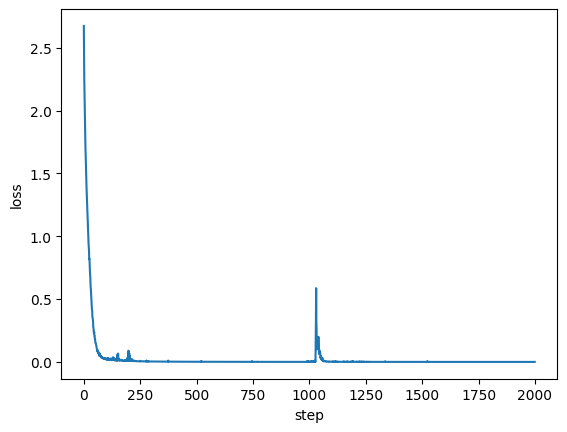

In [16]:
torch.manual_seed(0)
model = MiniFormer().to(device)          # fresh model
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
for step in range(1, 2001):
    src, tgt_in, tgt_out = make_batch(128)
    logits, _ = model(src, tgt_in)
    loss = F.cross_entropy(logits.reshape(-1, 13), tgt_out.reshape(-1))

    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

    if step % 200 == 0:
        print(f"step {step:4d} | loss {loss.item():.4f}")

plt.plot(losses); plt.xlabel("step"); plt.ylabel("loss"); plt.show()

* Generate and measure accuracy

In [17]:
@torch.no_grad()
def generate(model, src, n=6):
    model.eval()
    enc_out, src_mask = model.encode(src)
    tgt = torch.full((src.shape[0], 1), BOS, device=src.device)
    for _ in range(n):
        logits, _ = model.decode(tgt, enc_out, src_mask)
        nxt = logits[:, -1].argmax(-1, keepdim=True)   # last position's best token
        tgt = torch.cat([tgt, nxt], dim=1)
    return tgt[:, 1:]                                   # drop <bos>

src, _, tgt_out = make_batch(1000)
pred = generate(model, src)
truth = tgt_out[:, :-1]                                 # drop <eos>

seq_acc = (pred == truth).all(dim=1).float().mean().item()
tok_acc = (pred == truth).float().mean().item()
print(f"sequence accuracy: {seq_acc:.3f}")
print(f"token accuracy   : {tok_acc:.3f}")

for i in range(5):
    print(src[i].tolist(), "->", pred[i].tolist(), "| correct:", truth[i].tolist())

sequence accuracy: 1.000
token accuracy   : 1.000
[6, 2, 8, 5, 1, 5] -> [1, 2, 5, 5, 6, 8] | correct: [1, 2, 5, 5, 6, 8]
[3, 5, 1, 2, 3, 6] -> [1, 2, 3, 3, 5, 6] | correct: [1, 2, 3, 3, 5, 6]
[8, 2, 5, 1, 1, 7] -> [1, 1, 2, 5, 7, 8] | correct: [1, 1, 2, 5, 7, 8]
[7, 7, 7, 9, 2, 5] -> [2, 5, 7, 7, 7, 9] | correct: [2, 5, 7, 7, 7, 9]
[5, 9, 6, 6, 5, 1] -> [1, 5, 5, 6, 6, 9] | correct: [1, 5, 5, 6, 6, 9]


* Cross-attention heatmap

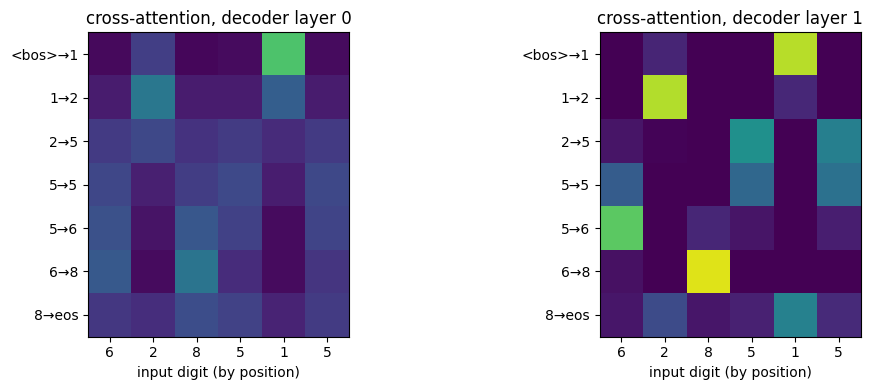

In [18]:
model.eval()
src = torch.tensor([[6, 2, 8, 5, 1, 5]]).to(device)
enc_out, src_mask = model.encode(src)

# Feed the CORRECT answer as decoder input (teacher forcing) to read the maps
tgt_in = torch.tensor([[BOS, 1, 2, 5, 5, 6, 8]]).to(device)
with torch.no_grad():
    _, cross_ws = model.decode(tgt_in, enc_out, src_mask)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, layer in zip(axes, [0, 1]):
    w = cross_ws[layer][0].mean(0).cpu()          # average over heads -> (7, 6)
    ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(6)); ax.set_xticklabels(src[0].tolist())
    ax.set_yticks(range(7)); ax.set_yticklabels(["<bos>→1", "1→2", "2→5", "5→5", "5→6", "6→8", "8→eos"])
    ax.set_xlabel("input digit (by position)")
    ax.set_title(f"cross-attention, decoder layer {layer}")
plt.tight_layout(); plt.show()

* causal test of the claim

In [19]:
def cross_map(src_list, tgt_list, layer=1):
    src = torch.tensor([src_list]).to(device)
    tgt_in = torch.tensor([[BOS] + tgt_list]).to(device)
    with torch.no_grad():
        enc_out, src_mask = model.encode(src)
        _, ws = model.decode(tgt_in, enc_out, src_mask)
    return ws[layer][0].mean(0).cpu()

# Same task, but put the minimum (1) at a different position
a = cross_map([6, 2, 8, 5, 1, 5], [1, 2, 5, 5, 6, 8])
b = cross_map([1, 2, 8, 5, 6, 5], [1, 2, 5, 5, 6, 8])

print("row <bos>→1, input A:", a[0].round(decimals=2).tolist())
print("row <bos>→1, input B:", b[0].round(decimals=2).tolist())

# Full-sequence check on a longer input, using the length-10 test from before
src2 = torch.randint(0, 10, (1000, 10)).to(device)
print("length-10 accuracy:", (generate(model, src2, n=10) == src2.sort(dim=1)[0]).float().mean().item())

row <bos>→1, input A: [0.0, 0.10000000149011612, 0.0, 0.0, 0.8899999856948853, 0.0]
row <bos>→1, input B: [0.9100000262260437, 0.09000000357627869, 0.0, 0.0, 0.0, 0.0]
length-10 accuracy: 0.33079999685287476


In [20]:
src2 = torch.randint(0, 10, (2000, 10)).to(device)
pred2 = generate(model, src2, n=10)
truth2 = src2.sort(dim=1)[0]

pos_acc = (pred2 == truth2).float().mean(dim=0)
for i, a in enumerate(pos_acc.tolist()):
    print(f"output position {i}: {a:.3f}")

# Also: what fraction of predictions are a valid digit at all?
print("\nfraction of predicted tokens that are digits 0-9:", (pred2 < 10).float().mean().item())

output position 0: 0.954
output position 1: 0.549
output position 2: 0.247
output position 3: 0.089
output position 4: 0.024
output position 5: 0.006
output position 6: 0.000
output position 7: 0.578
output position 8: 0.482
output position 9: 0.453

fraction of predicted tokens that are digits 0-9: 0.8858499526977539


In [21]:
# 1) What token does the free-running model write at output position 6?
src2 = torch.randint(0, 10, (2000, 10)).to(device)
pred2 = generate(model, src2, n=10)
print("token counts at output position 6 (index = token id):")
print(torch.bincount(pred2[:, 6], minlength=13).tolist())

# 2) Teacher-forced per-position accuracy on length-10 inputs
@torch.no_grad()
def tf_pos_acc(model, n, count=2000):
    model.eval()
    src = torch.randint(0, 10, (count, n)).to(device)
    srt = src.sort(dim=1)[0]
    bos = torch.full((count, 1), BOS, device=device)
    tgt_in = torch.cat([bos, srt], dim=1)[:, :-1]      # <bos> + first n-1 sorted digits
    logits, _ = model(src, tgt_in)
    return (logits.argmax(-1) == srt).float().mean(0)

print("\nteacher-forced, length 10:")
for i, a in enumerate(tf_pos_acc(model, 10).tolist()):
    print(f"  output position {i}: {a:.3f}")

# 3) Length sweep with both metrics
print()
for n in range(6, 11):
    s = torch.randint(0, 10, (1000, n)).to(device)
    p = generate(model, s, n=n)
    t = s.sort(dim=1)[0]
    print(f"length {n}: token acc {(p == t).float().mean().item():.3f} "
          f"| sequence acc {(p == t).all(1).float().mean().item():.3f}")

token counts at output position 6 (index = token id):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2000]

teacher-forced, length 10:
  output position 0: 0.961
  output position 1: 0.581
  output position 2: 0.437
  output position 3: 0.343
  output position 4: 0.208
  output position 5: 0.048
  output position 6: 0.000
  output position 7: 0.497
  output position 8: 0.618
  output position 9: 0.416

length 6: token acc 1.000 | sequence acc 1.000
length 7: token acc 0.699 | sequence acc 0.000
length 8: token acc 0.420 | sequence acc 0.000
length 9: token acc 0.333 | sequence acc 0.000
length 10: token acc 0.334 | sequence acc 0.000


In [22]:
def make_batch_n(B, n):
    src = torch.randint(0, 10, (B, n))
    srt, _ = src.sort(dim=1)
    bos = torch.full((B, 1), BOS)
    eos = torch.full((B, 1), EOS)
    return (src.to(device),
            torch.cat([bos, srt], 1).to(device),
            torch.cat([srt, eos], 1).to(device))

torch.manual_seed(0)
model2 = MiniFormer().to(device)
opt = torch.optim.Adam(model2.parameters(), lr=1e-3)

for step in range(1, 4001):
    n = int(torch.randint(3, 13, (1,)))            # length 3..12
    src, tgt_in, tgt_out = make_batch_n(128, n)
    logits, _ = model2(src, tgt_in)
    loss = F.cross_entropy(logits.reshape(-1, 13), tgt_out.reshape(-1))
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)   # tame the spikes
    opt.step()
    if step % 500 == 0:
        print(f"step {step:4d} | loss {loss.item():.4f} (length {n})")

# Same length sweep, plus lengths outside the training range
for n in [6, 10, 12, 14, 16]:
    s = torch.randint(0, 10, (1000, n)).to(device)
    p = generate(model2, s, n=n)
    t = s.sort(dim=1)[0]
    print(f"length {n:2d}: token acc {(p == t).float().mean().item():.3f} "
          f"| sequence acc {(p == t).all(1).float().mean().item():.3f}")

step  500 | loss 0.1464 (length 11)
step 1000 | loss 0.0497 (length 12)
step 1500 | loss 0.0225 (length 4)
step 2000 | loss 0.0283 (length 11)
step 2500 | loss 0.0005 (length 12)
step 3000 | loss 0.0336 (length 7)
step 3500 | loss 0.0002 (length 9)
step 4000 | loss 0.0079 (length 12)
length  6: token acc 0.988 | sequence acc 0.956
length 10: token acc 0.997 | sequence acc 0.989
length 12: token acc 0.997 | sequence acc 0.984
length 14: token acc 0.573 | sequence acc 0.014
length 16: token acc 0.312 | sequence acc 0.000


In [24]:
import copy
model3 = copy.deepcopy(model2)
with torch.no_grad():
    # Reuse trained slots 8..11 for untrained slots 12..15
    model3.pos.weight[12:16] = model3.pos.weight[8:12]

for name, m in [("original", model2), ("patched  ", model3)]:
    for n in [14, 16]:
        s = torch.randint(0, 10, (1000, n)).to(device)
        p = generate(m, s, n=n)
        t = s.sort(dim=1)[0]
        print(f"{name} length {n}: token acc {(p == t).float().mean().item():.3f} "
              f"| sequence acc {(p == t).all(1).float().mean().item():.3f}")

original length 14: token acc 0.581 | sequence acc 0.019
original length 16: token acc 0.303 | sequence acc 0.000
patched   length 14: token acc 0.827 | sequence acc 0.213
patched   length 16: token acc 0.620 | sequence acc 0.021
